In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import * 
from ESMCBA import other_utils

In [3]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [4]:
pd.read_csv('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201all_binders_mhc_flurry.csv')

,allele,peptide,mhcflurry_affinity,mhcflurry_affinity_percentile,mhcflurry_processing_score,mhcflurry_presentation_score,mhcflurry_presentation_percentile
0,A0201,RAKLLGAEEK,27739.022368,28.874250,0.044665,0.004254,62.744674
1,A0201,GRAKLLGAEEK,26034.732016,22.627125,0.151088,0.006578,37.359049
2,A0201,FGLAKLLGA,1191.320133,1.868375,0.350082,0.211257,1.767120
3,A0201,GLAKLLGAEEK,16518.973155,8.905000,0.151236,0.010201,22.192310
4,A0201,LAKLLGAEEK,26911.222822,25.389875,0.017940,0.003987,99.286603
...,...,...,...,...,...,...,...
13803,A0201,DQPMVVLPGN,27483.259918,27.623500,0.004164,0.003722,99.286603
13804,A0201,PQPAFVLPGP,25837.979333,22.627125,0.020467,0.004184,62.744674
13805,A0201,AQPAVVLPGV,87.356128,0.554750,0.355540,0.775550,0.316766
13806,A0201,PAPAFVLPGP,24441.563067,18.527250,0.008400,0.004232,62.744674


In [5]:
mhcflurry = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201all_binders_mhc_flurry.csv')

In [6]:
mhcflurry['mhc_log'] = mhcflurry['mhcflurry_affinity'].apply(np.log10)

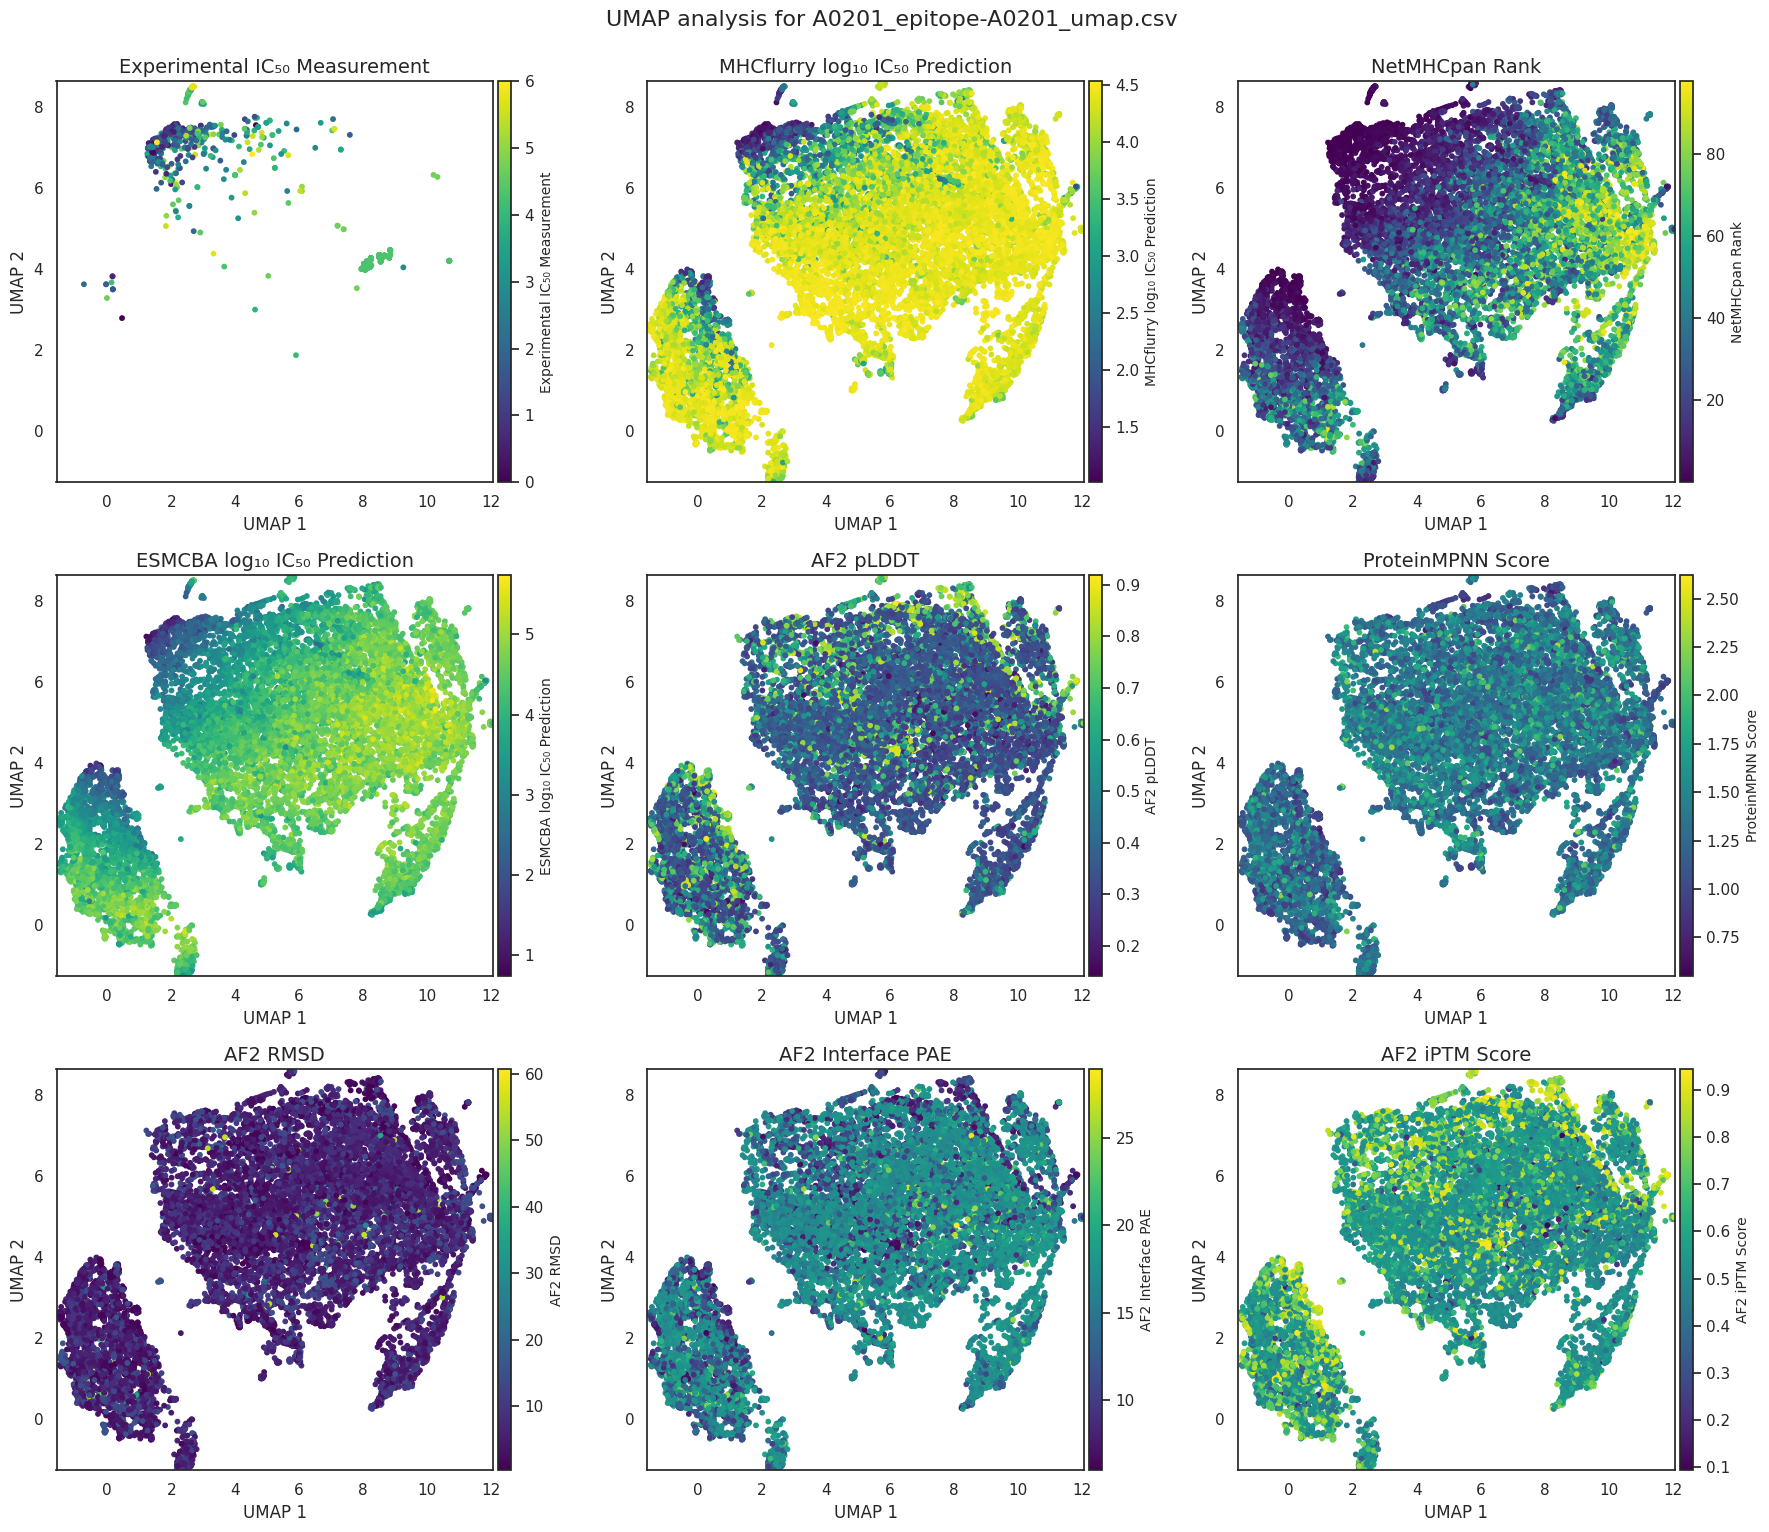

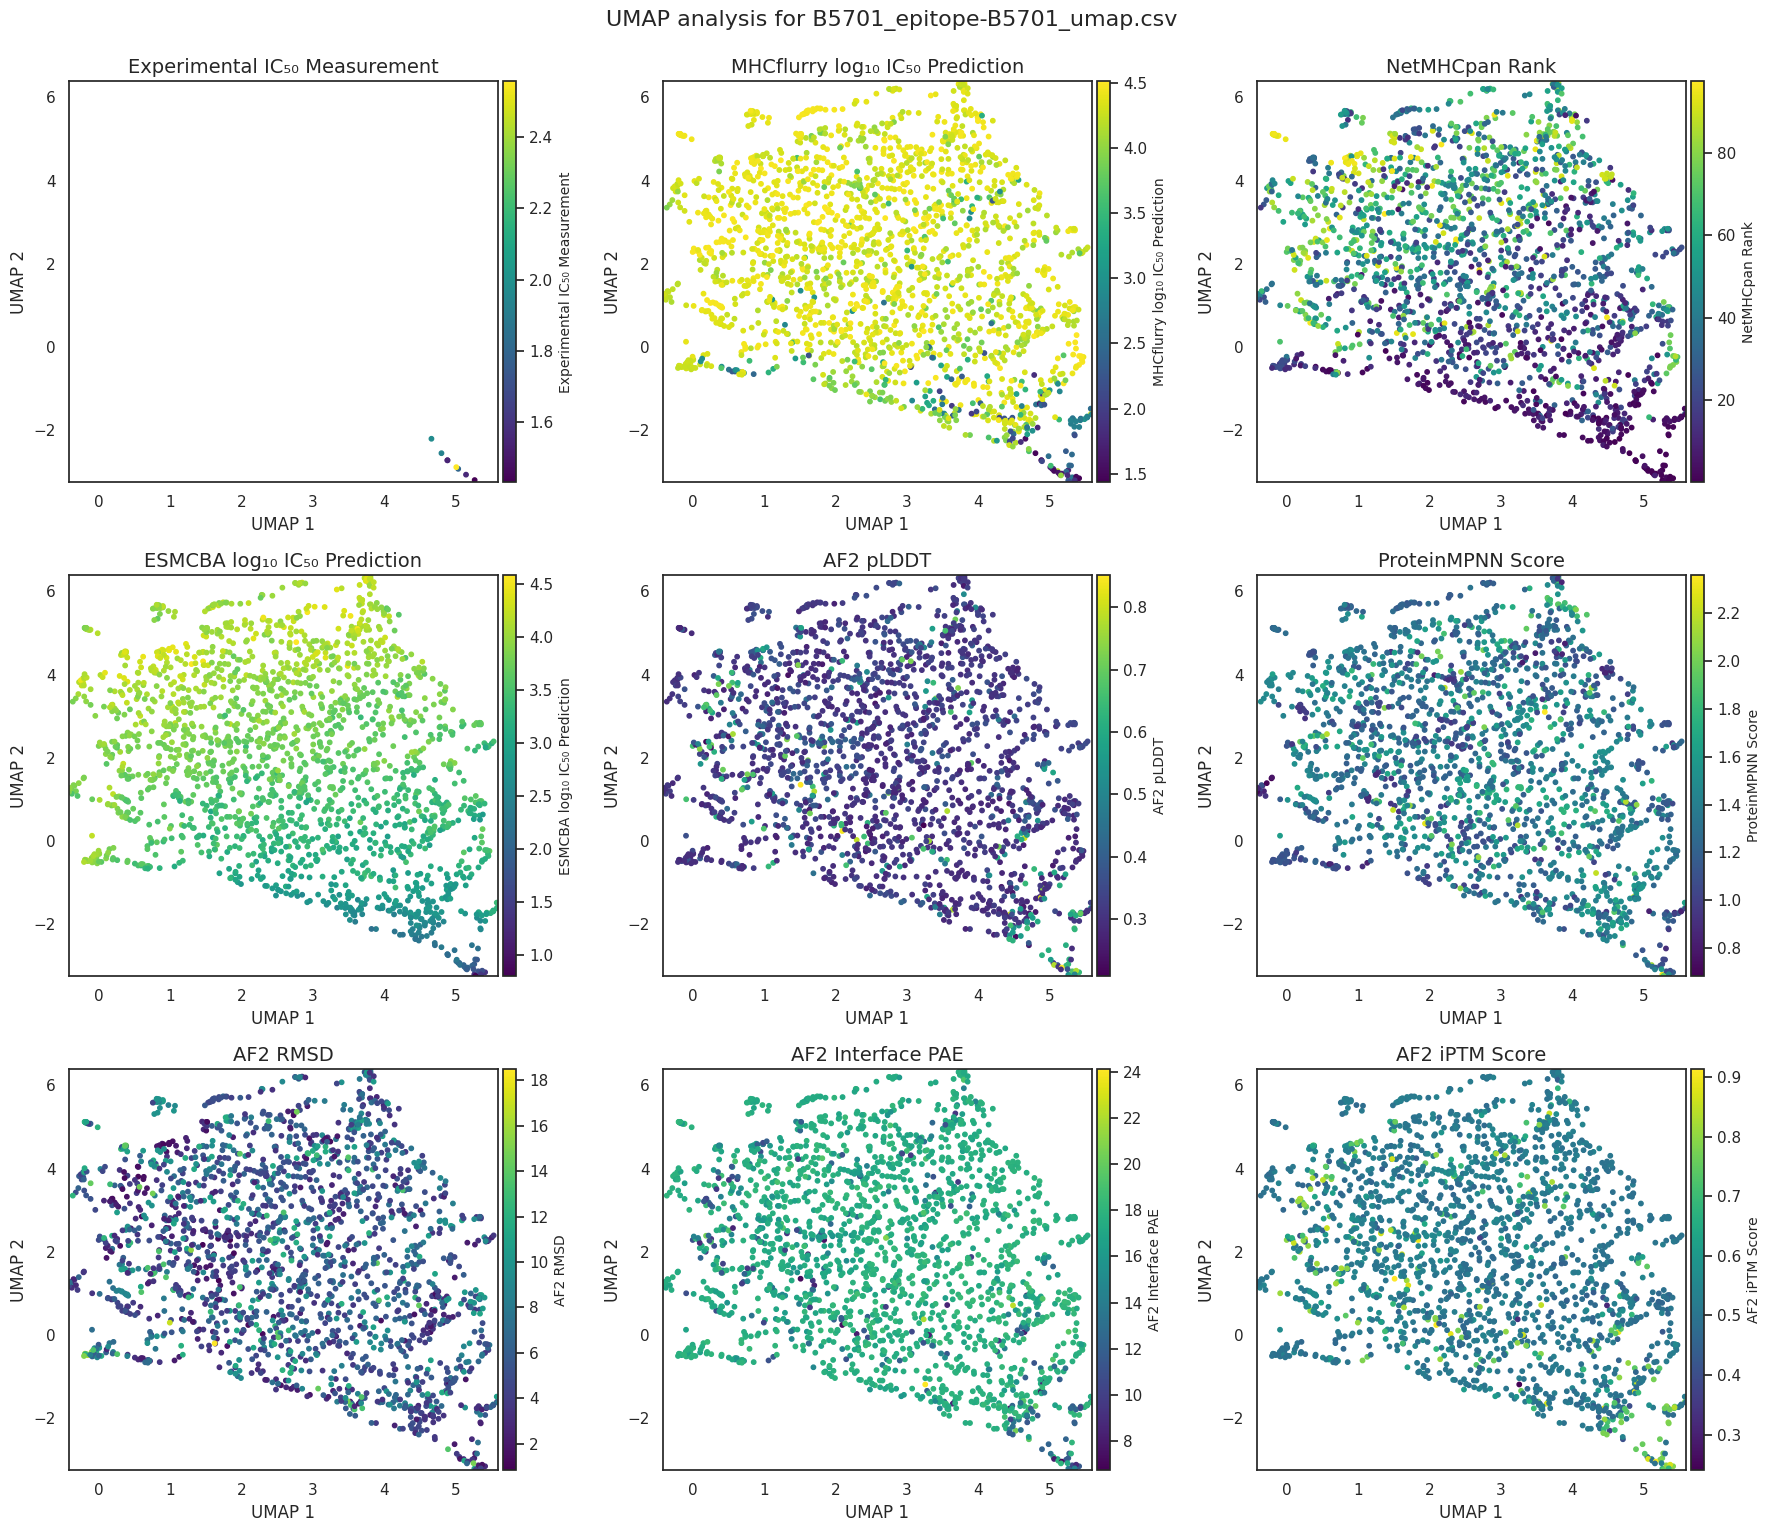

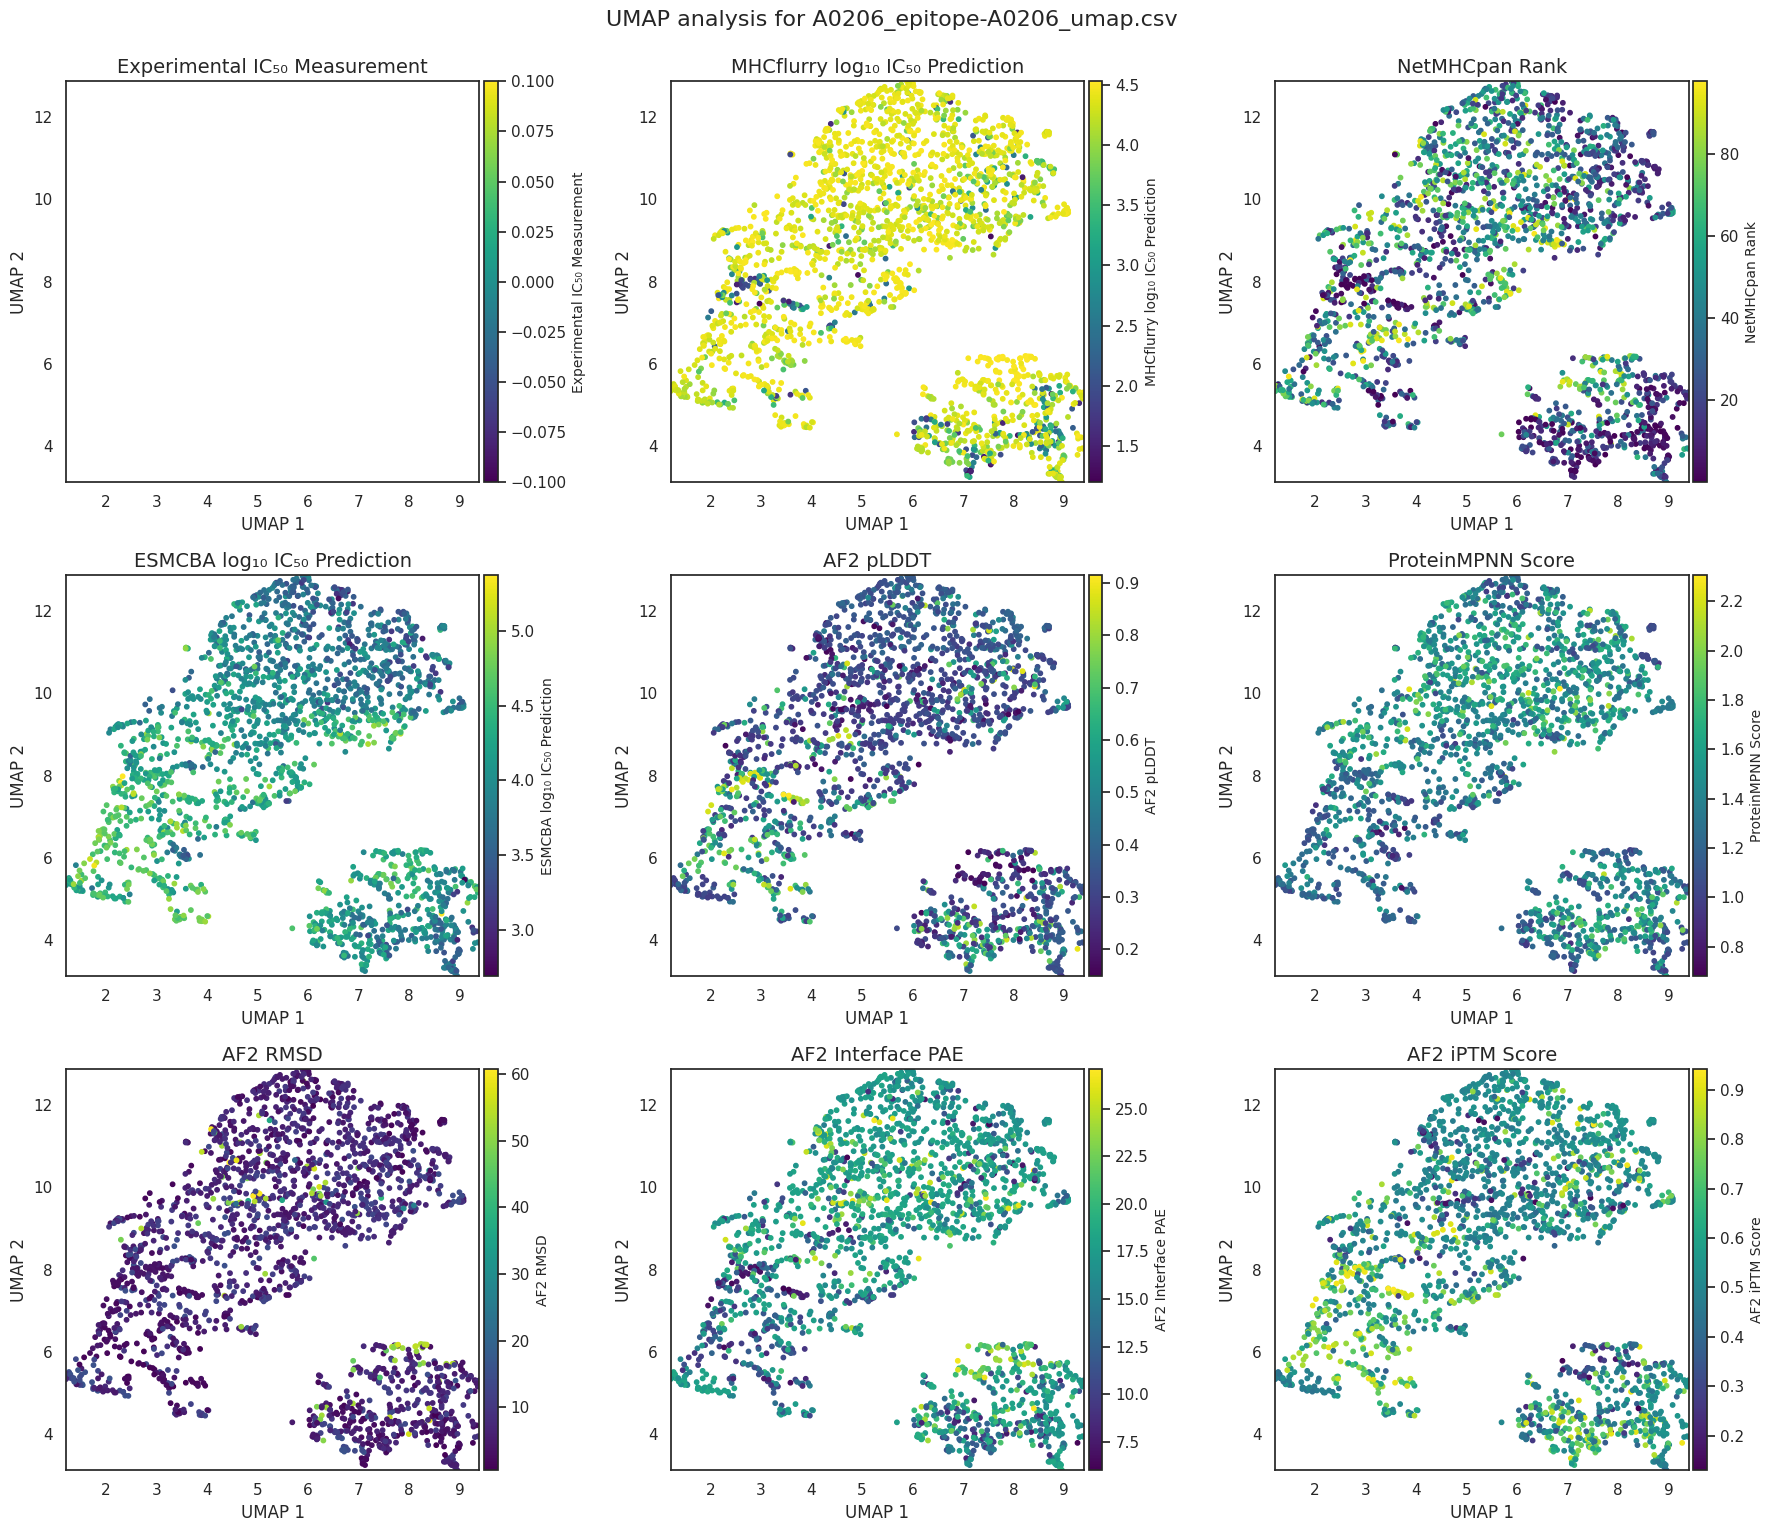

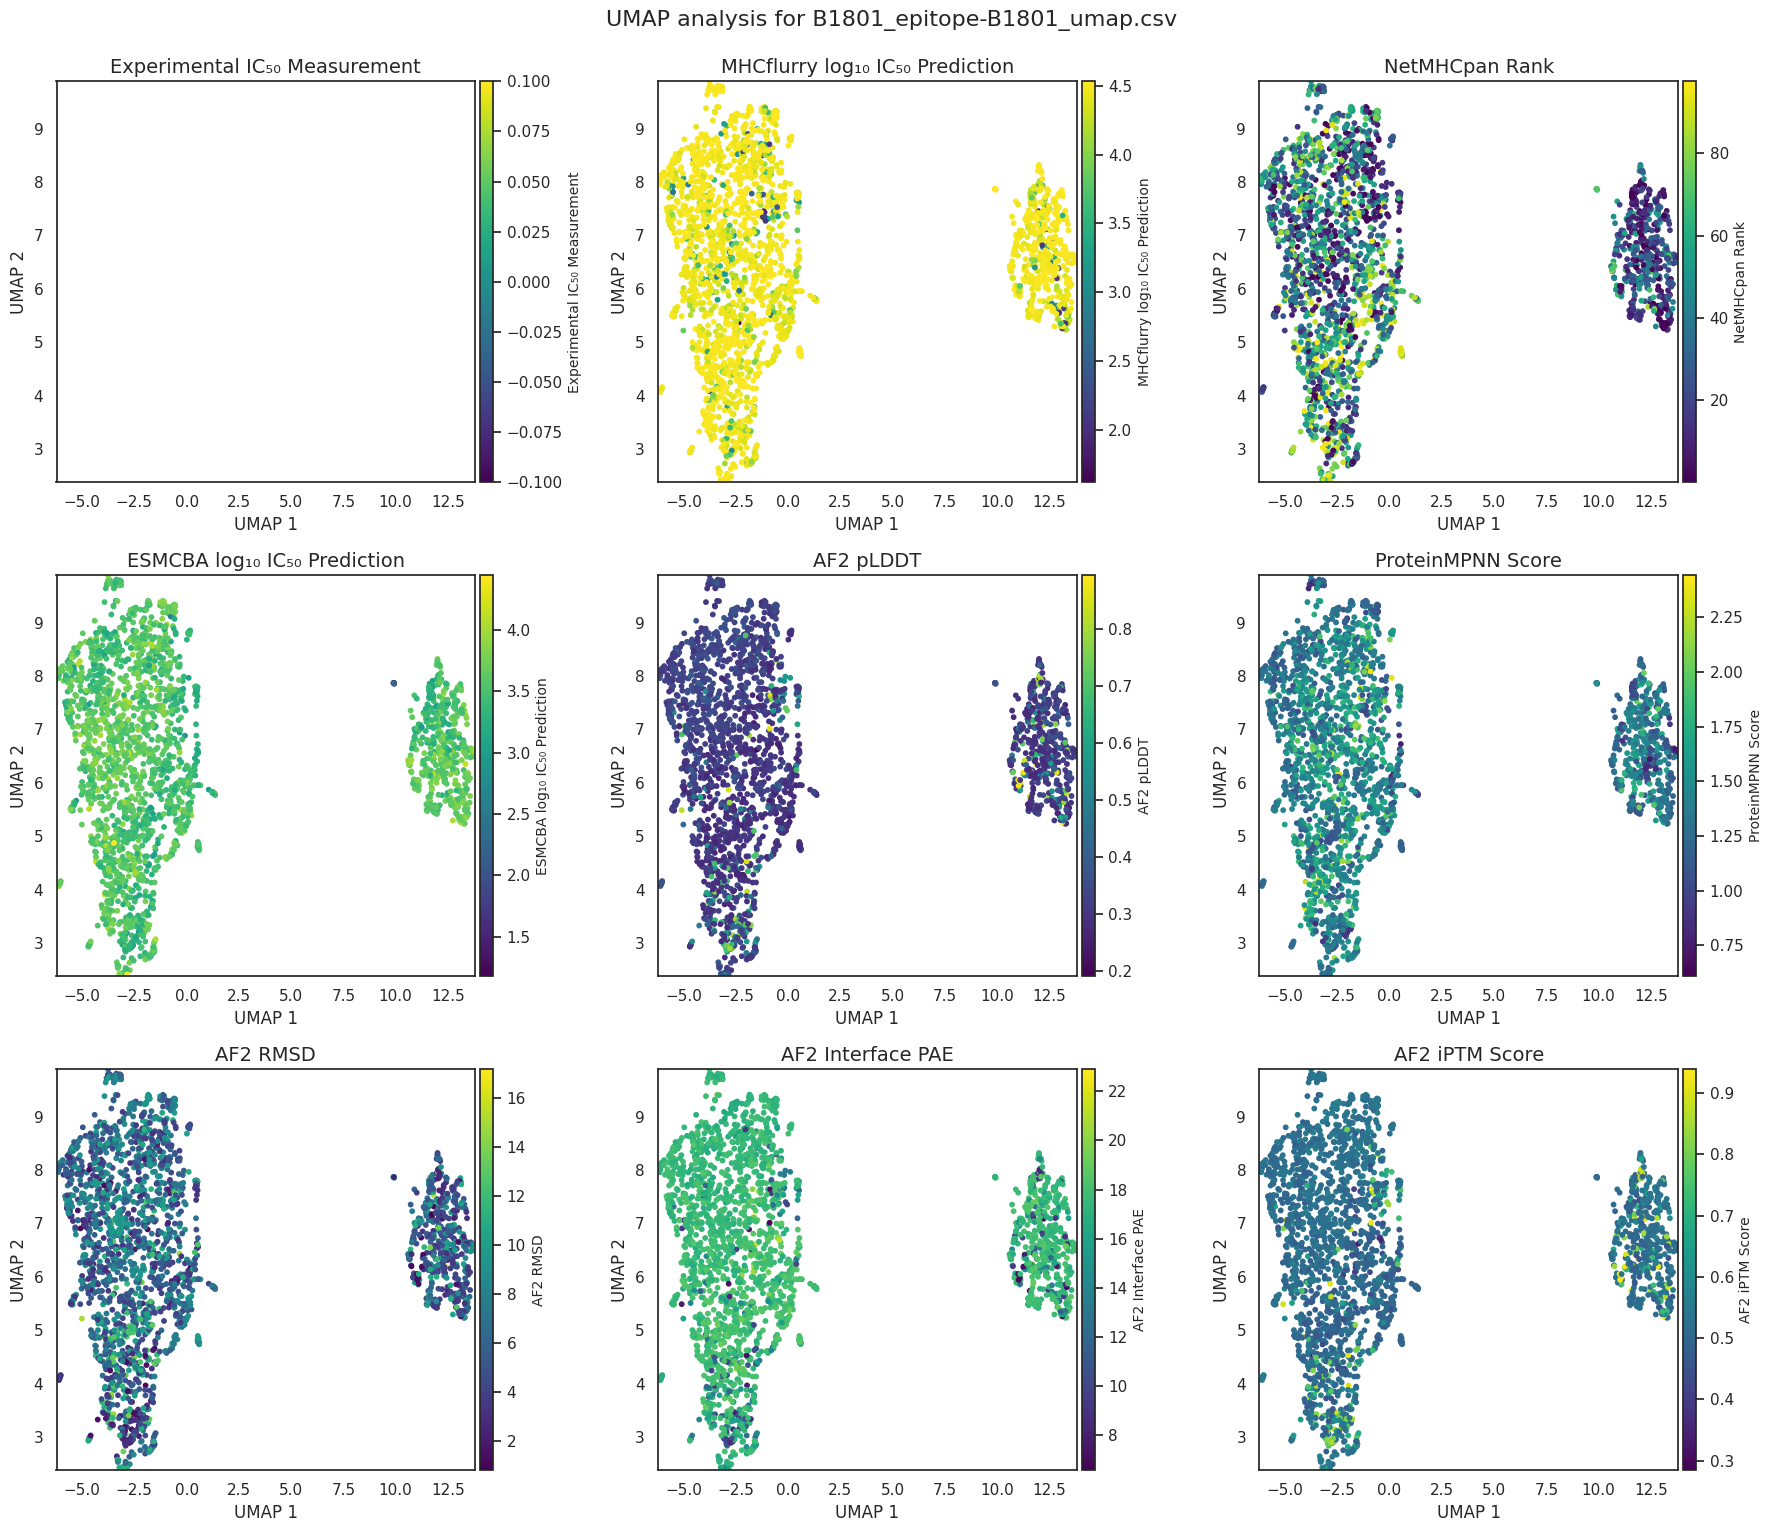

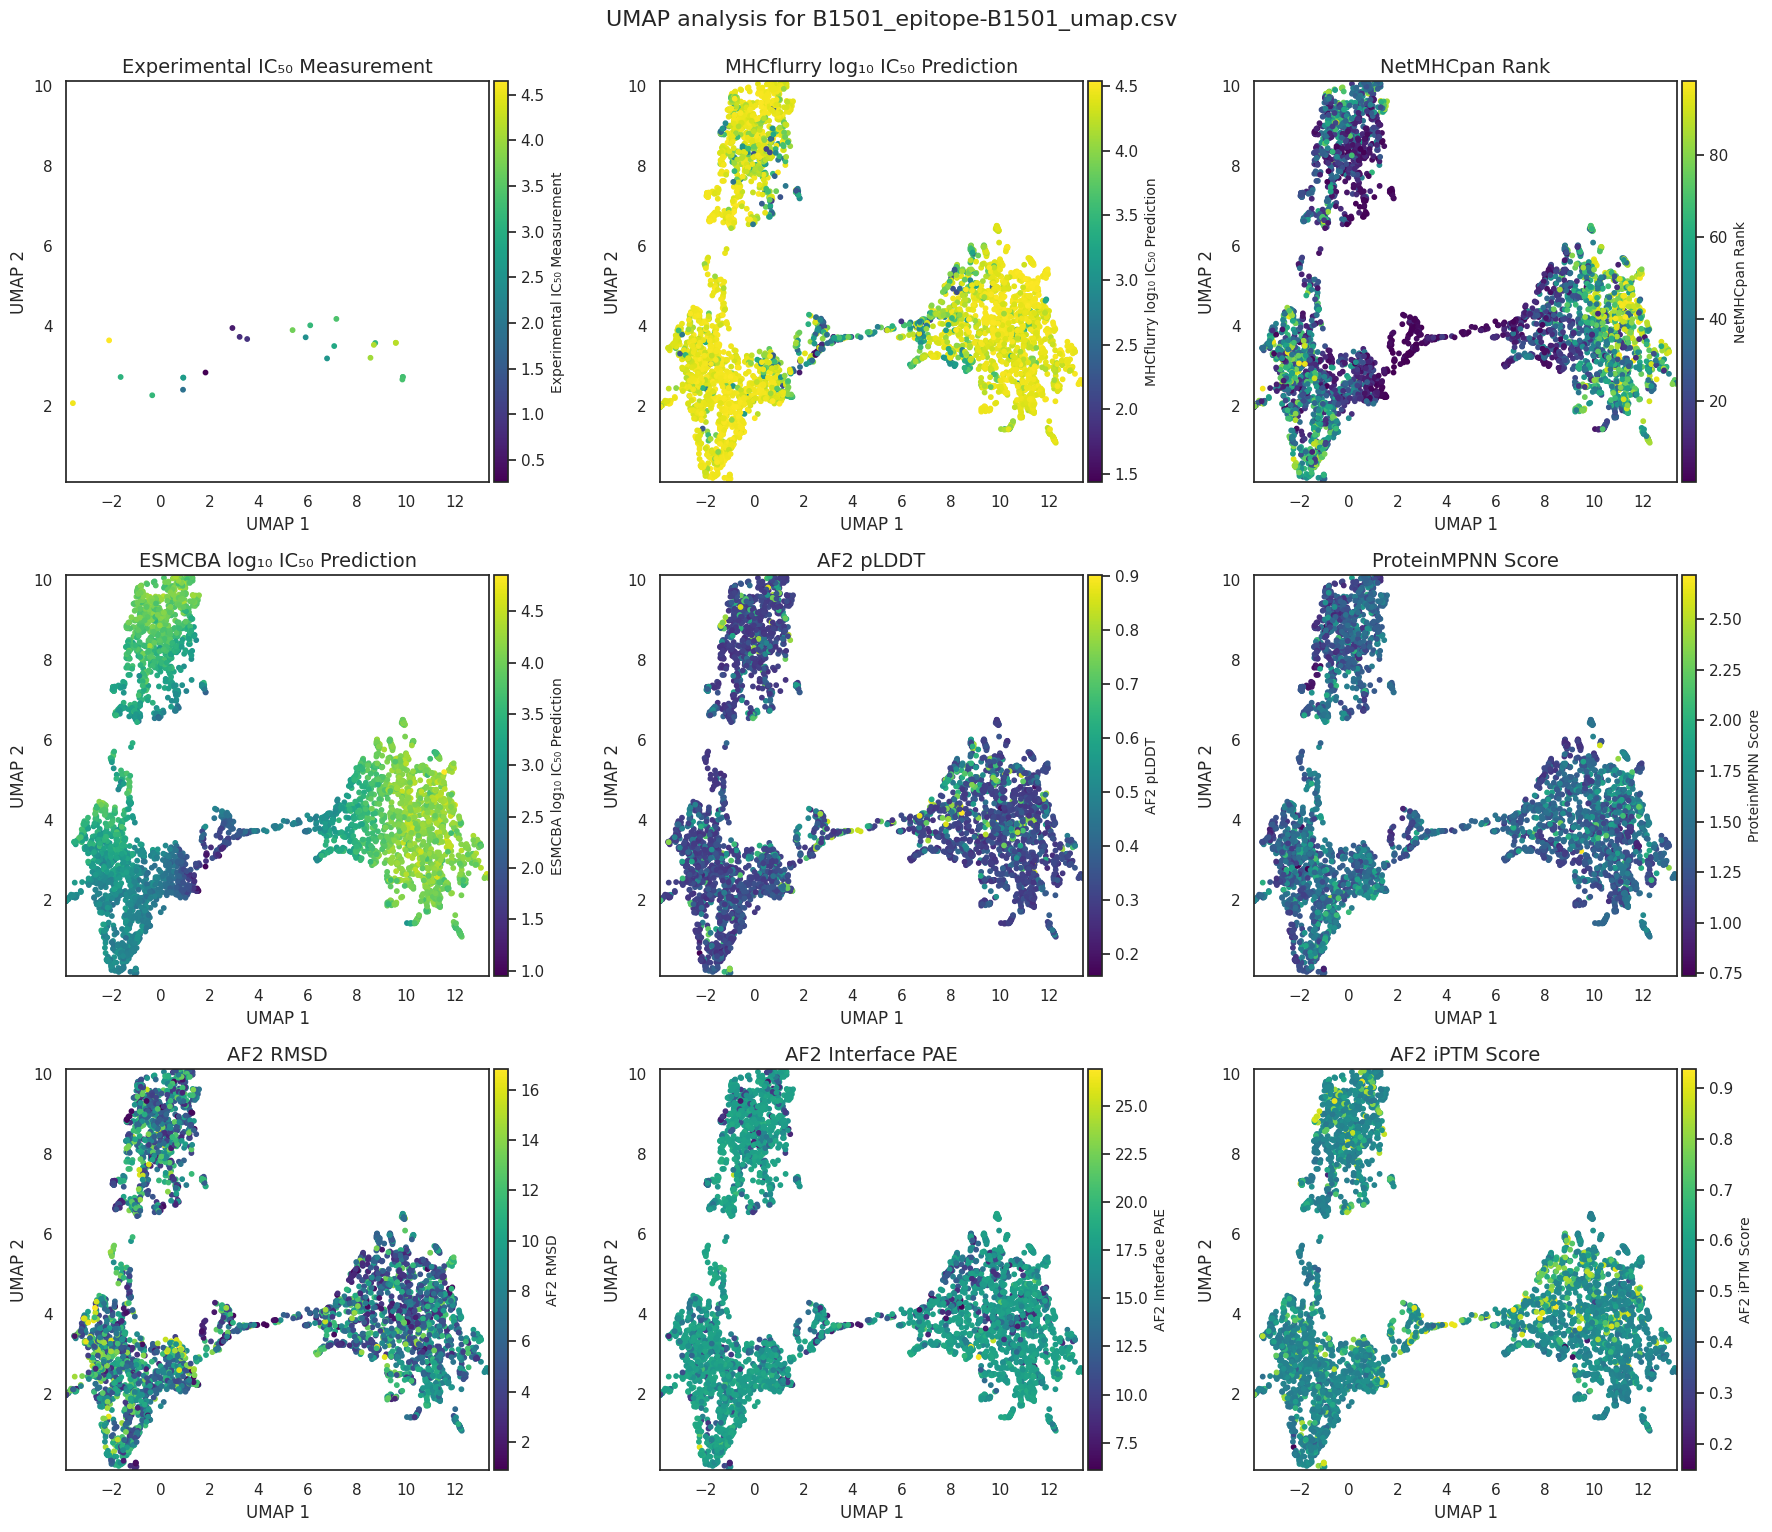

In [28]:
# Load the shared peptide datasets
rfd_peptides_all = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/rdfiffusion_output_peptides.csv')
peptides_eval_set_ESMCBA = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_of_models.csv')

# Get list of all UMAP files
umap_files = glob.glob('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/*_umap.csv')

# Create empty list to collect the merged DataFrames
all_predictions = []

pretty_names = {
    'measured': 'Experimental IC₅₀ Measurement',
    'mhc_log_y': 'MHCflurry log₁₀ IC₅₀ Prediction',
    'BA_Rank': 'NetMHCpan Rank',
    'prediction_x': 'ESMCBA log₁₀ IC₅₀ Prediction',
    'plddt': 'AF2 pLDDT',
    'mpnn': 'ProteinMPNN Score',
    'rmsd': 'AF2 RMSD',
    'i_pae': 'AF2 Interface PAE',
    'i_ptm': 'AF2 iPTM Score'
}

sns.set_style("white")

# Now loop over each file
for file in umap_files:
    filename = os.path.basename(file)
    hla = filename.split('_')[0]  # e.g., 'B1501' from 'B1501_epitope-B1501_umap.csv'


    if 'epitope' not in filename:
        continue

    # Load UMAP predictions
    ESCMBA_predictions = pd.read_csv(file)


    mhcflurry = pd.read_csv(f'/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/{hla}all_binders_mhc_flurry.csv')
    mhcflurry['mhc_log'] = mhcflurry['mhcflurry_affinity'].apply(np.log10)

    # try:
    netmhcspan = pd.read_csv(f'/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/all_binders_{hla}_netmhc.xls', sep = '\t', header = 1)
    # exscept:

    # if mhc_log.empty:   
    #     print(f"Warning: No mhc_log data for {hla}. Skipping this file.")
    #     continue

    # Subset RFD peptides for this HLA
    rfd_peptides = rfd_peptides_all[rfd_peptides_all['hla_allele'] == hla]

    # Skip if no peptides
    if len(rfd_peptides) == 0:
        continue

    # Subset evaluation set
    peptides_eval = peptides_eval_set_ESMCBA[peptides_eval_set_ESMCBA['Model'] == f'{hla} epitope']

    # Merge data
    ESCMBA_predictions = pd.merge(ESCMBA_predictions, peptides_eval, on='sequence', how='left')
    ESCMBA_predictions = pd.merge(ESCMBA_predictions, rfd_peptides, left_on='sequence', right_on='epitope', how='left')
    ESCMBA_predictions = pd.merge(ESCMBA_predictions, mhcflurry[['peptide','mhc_log','mhcflurry_presentation_score']], left_on='sequence', right_on='peptide', how='left')
    ESCMBA_predictions = pd.merge(ESCMBA_predictions, netmhcspan[['Peptide','BA_Rank']], left_on='sequence', right_on='Peptide', how='left')
    
    

    # Add a column for HLA for traceability
    ESCMBA_predictions['HLA'] = hla

    # Append this merged df to list
    all_predictions.append(ESCMBA_predictions)

    # ---- (your plotting code stays exactly the same) ----
    hue_columns = [
        'measured', 'mhc_log_y', 'BA_Rank',
        'prediction_x', 'plddt', 'mpnn', 'rmsd', 'i_pae', 'i_ptm'
    ]

    n_cols = 3
    n_rows = (len(hue_columns) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for idx, hue_var in enumerate(hue_columns):
        ax = axes[idx]
        subset = ESCMBA_predictions

        points = ax.scatter(
            subset['UMAP_1'],
            subset['UMAP_2'],
            c=subset[hue_var],
            cmap='viridis',
            s=10,
            edgecolor=None
        )

        title_str = pretty_names.get(hue_var, hue_var)
        ax.set_title(f'{title_str}', fontsize=14)

        ax.set_xlabel('UMAP 1', fontsize=12)
        ax.set_ylabel('UMAP 2', fontsize=12)
        ax.set_xlim(subset['UMAP_1'].min(), subset['UMAP_1'].max())
        ax.set_ylim(subset['UMAP_2'].min(), subset['UMAP_2'].max())

        cbar = fig.colorbar(points, ax=ax, orientation='vertical', pad=0.01, aspect=30)
        cbar.set_label(title_str, fontsize=10)

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle(f'UMAP analysis for {filename}', fontsize=16, y=1.02)

    #save figures as PDF
    output_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures/'
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f'{hla}_UMAP_analysis.pdf')
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()


# ====> AFTER the loop finishes:
# Concatenate all merged DataFrames together
final_df = pd.concat(all_predictions, ignore_index=True)

# # Save it to CSV (or pickle, up to you)
# final_df.to_csv('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/ALL_MERGED_UMAP_predictions.csv', index=False)

# print(f"✅ Saved merged UMAP dataframe with shape {final_df.shape}")


In [20]:
final_df['prediction_x']

0        4.583677
1        4.583677
2        4.581459
3        3.497342
4        4.270145
           ...   
24825    3.847634
24826    3.909594
24827    3.979149
24828    3.278242
24829    3.754847
Name: prediction_x, Length: 24830, dtype: float64

In [19]:
final_df['mhc_log_y']

0        4.443091
1        4.443091
2        4.415553
3        3.076028
4        4.217983
           ...   
24825    3.547536
24826    4.234543
24827    4.034669
24828    4.173962
24829    4.406014
Name: mhc_log_y, Length: 24830, dtype: float64

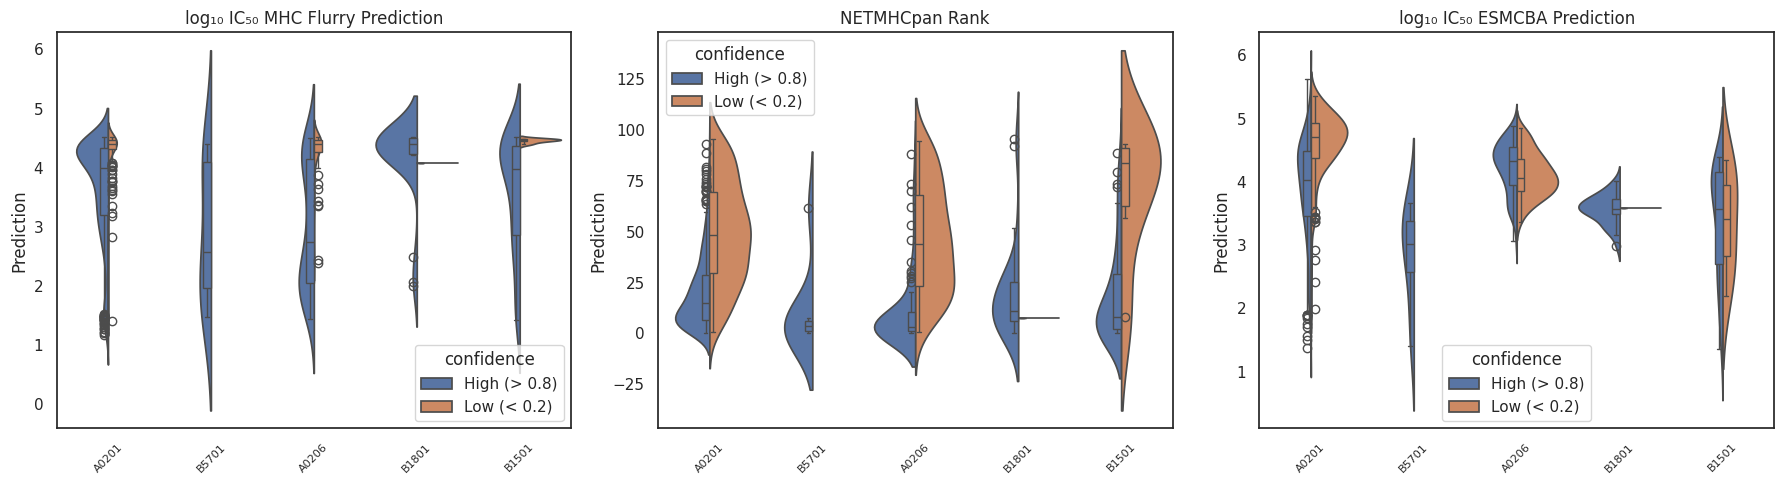

In [27]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

# ----------------------------------------
# 0.  final_df must already exist
# ----------------------------------------
# e.g.:
# final_df = pd.read_pickle("ALL_MERGED_UMAP_predictions.pkl")

metrics = ['mhc_log_y', 'BA_Rank', 'prediction_x']
pretty_name = {
    'mhc_log_y':    'log₁₀ IC₅₀ MHC Flurry Prediction',
    'BA_Rank':      'NETMHCpan Rank',
    'prediction_x': 'log₁₀ IC₅₀ ESMCBA Prediction'
}

# ----------------------------------------
# 1.  build plotting table — *only* rows <0.2 or >0.8
# ----------------------------------------
df_plot = (
    final_df
      .loc[:, metrics + ['plddt', 'HLA']]
      .dropna(subset=metrics + ['plddt', 'HLA'])
      .query('plddt > 0.8 or plddt < 0.2')              # keep only extremes
      .assign(confidence=lambda d:
              np.where(d['plddt'] > 0.8, 'High (> 0.8)', 'Low (< 0.2)'))
)

# (optional) cap at the 10 most frequent HLAs for readability
top_hlas = df_plot['HLA'].value_counts().head(10).index
df_plot  = df_plot[df_plot['HLA'].isin(top_hlas)]

# melt to long format
df_long = df_plot.melt(id_vars=['HLA', 'confidence'],
                       value_vars=metrics,
                       var_name='metric',
                       value_name='value')

# ----------------------------------------
# 2.  violin + box plots
# ----------------------------------------
sns.set(style="white")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    subset = df_long[df_long['metric'] == metric]

    sns.violinplot(data=subset,
                   x='HLA', y='value', hue='confidence',
                   split=True, inner=None, dodge=True,
                   ax=ax, legend=True)

    sns.boxplot(data=subset,
                x='HLA', y='value', hue='confidence',
                width=0.15, #, showfliers=False,
                # showcaps=True, dodge=True,
                ax=ax, legend=False)
                # boxprops={'zorder': 3}, linewidth=1)

    ax.set_title(pretty_name[metric])
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('Prediction')

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
# leg = fig.legend(handles[:2], ['Low (< 0.2)', 'High (> 0.8)'],
#                  title='pLDDT Confidence', ncol=2, loc='upper center',
#                  bbox_to_anchor=(0.5, 1.08), frameon=True)
# leg.get_frame().set_facecolor('white')
# leg.get_frame().set_edgecolor('black')

# fig.suptitle('HLA-specific Score Distributions for Extreme-confidence Structures', y=1.15)
plt.tight_layout()

output_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures/'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f'PREDICTIONS.pdf')
plt.savefig(output_path, bbox_inches='tight')

plt.show()


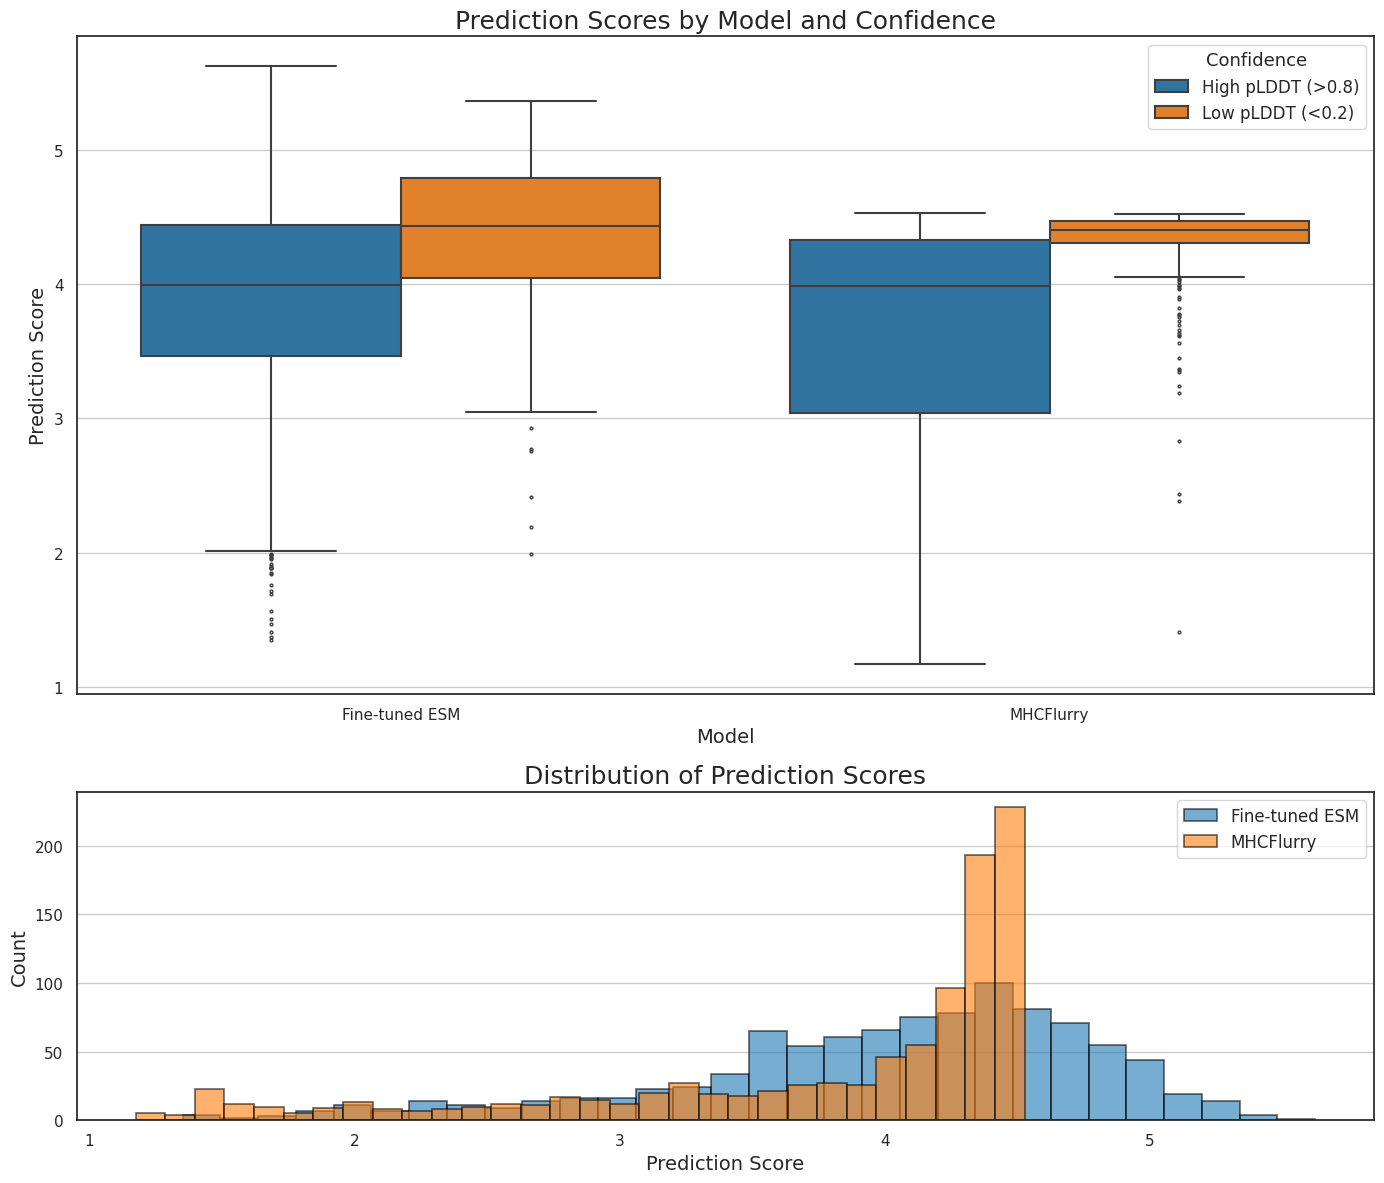

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume final_df already exists

# Subset high and low pLDDT groups
high_confidence = final_df[final_df['plddt'] > 0.8].copy()
low_confidence = final_df[final_df['plddt'] < 0.2].copy()

# Label them
high_confidence['Confidence'] = 'High pLDDT (>0.8)'
low_confidence['Confidence'] = 'Low pLDDT (<0.2)'

# Combine
plot_df = pd.concat([high_confidence, low_confidence], ignore_index=True)

# Melt the DataFrame to long format
plot_df_melted = plot_df.melt(
    id_vars=['HLA', 'Confidence'],
    value_vars=['prediction_x', 'mhc_log_y'],
    var_name='Model',
    value_name='Score'
)

# Map model names
model_name_map = {
    'prediction_x': 'Fine-tuned ESM',
    'mhc_log_y': 'MHCFlurry'
}
plot_df_melted['Model'] = plot_df_melted['Model'].map(model_name_map)

# ---------------------------
# Plot settings
sns.set_style('white')
colors = ['#1f77b4', '#ff7f0e']  # Default seaborn blue and orange

# Set up figure with gridspec (2 rows, 1 column)
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1]})

# 1) BOX PLOT SIDE BY SIDE
sns.boxplot(
    data=plot_df_melted,
    x='Model',
    y='Score',
    hue='Confidence',
    palette=colors,
    fliersize=2,
    linewidth=1.5,
    ax=ax_box
)

# Outline boxes with black
for patch in ax_box.artists:
    patch.set_edgecolor('black')

ax_box.set_title('Prediction Scores by Model and Confidence', fontsize=18)
ax_box.set_xlabel('Model', fontsize=14)
ax_box.set_ylabel('Prediction Score', fontsize=14)
ax_box.legend(title='Confidence', fontsize=12, title_fontsize=13)
ax_box.grid(True, axis='y')

# 2) HISTOGRAM
# Separate histograms for Fine-tuned ESM and MHCFlurry
for idx, model in enumerate(['Fine-tuned ESM', 'MHCFlurry']):
    subset = plot_df_melted[plot_df_melted['Model'] == model]
    ax_hist.hist(
        subset['Score'],
        bins=30,
        alpha=0.6,
        label=model,
        color=colors[idx],
        edgecolor='black',
        linewidth=1.2
    )

ax_hist.set_title('Distribution of Prediction Scores', fontsize=18)
ax_hist.set_xlabel('Prediction Score', fontsize=14)
ax_hist.set_ylabel('Count', fontsize=14)
ax_hist.legend(fontsize=12)
ax_hist.grid(True, axis='y')

plt.tight_layout()
plt.show()


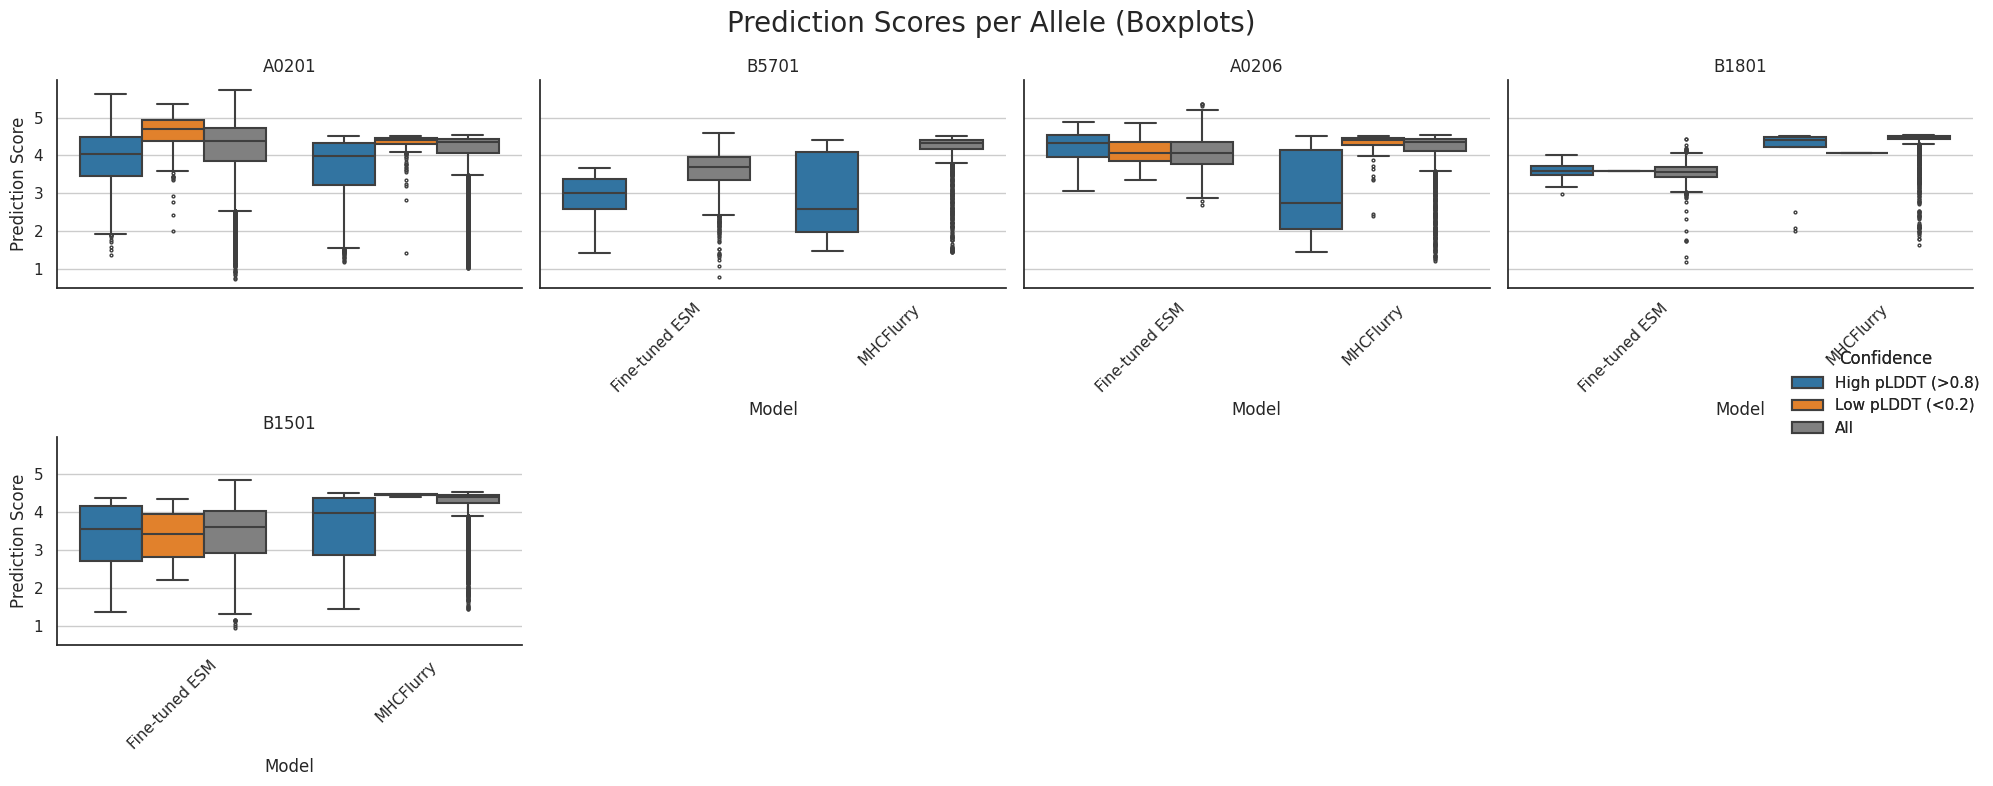

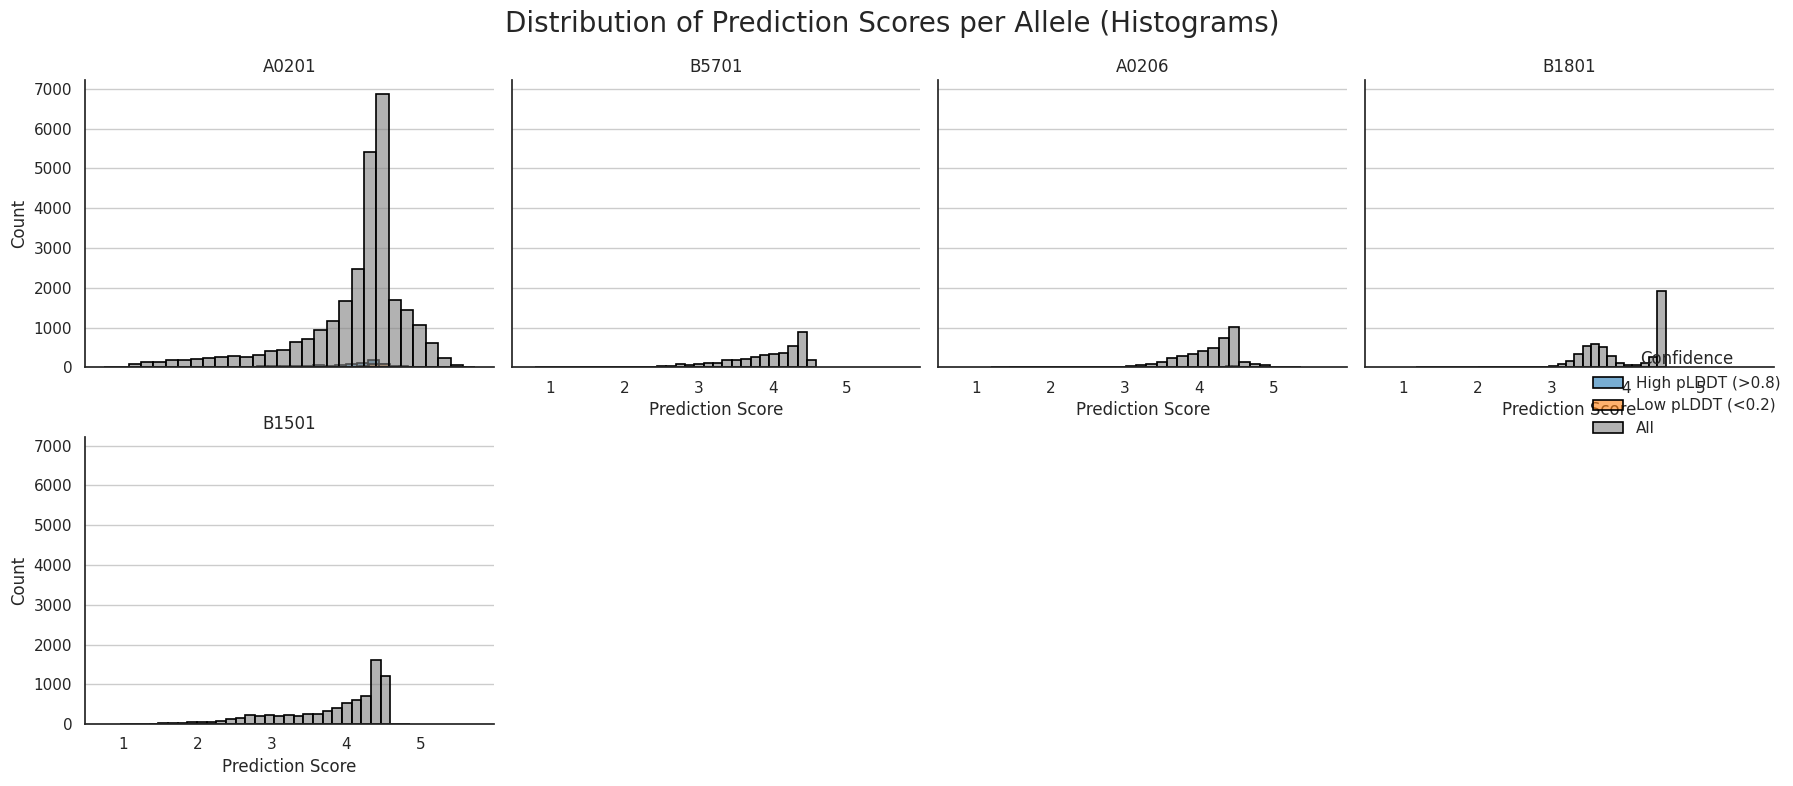

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume final_df already exists

# Subset high, low and all
high_confidence = final_df[final_df['plddt'] > 0.8].copy()
low_confidence = final_df[final_df['plddt'] < 0.2].copy()
all_data = final_df.copy()

# Label them
high_confidence['Confidence'] = 'High pLDDT (>0.8)'
low_confidence['Confidence'] = 'Low pLDDT (<0.2)'
all_data['Confidence'] = 'All'

# Combine
plot_df = pd.concat([high_confidence, low_confidence, all_data], ignore_index=True)

# Melt the DataFrame
plot_df_melted = plot_df.melt(
    id_vars=['HLA', 'Confidence'],
    value_vars=['prediction_x', 'mhc_log_y'],
    var_name='Model',
    value_name='Score'
)

# Map model names
model_name_map = {
    'prediction_x': 'Fine-tuned ESM',
    'mhc_log_y': 'MHCFlurry'
}
plot_df_melted['Model'] = plot_df_melted['Model'].map(model_name_map)

# ---------------------------
# Plot settings
sns.set_style('white')
colors = {
    'High pLDDT (>0.8)': '#1f77b4',  # blue
    'Low pLDDT (<0.2)': '#ff7f0e',   # orange
    'All': 'gray'                    # neutral gray
}

# =============================
# First: BOX PLOT per allele
# =============================

g = sns.catplot(
    data=plot_df_melted,
    x='Model',
    y='Score',
    hue='Confidence',
    col='HLA',
    kind='box',
    palette=colors,
    col_wrap=4,
    height=4,
    aspect=1,
    fliersize=2,
    linewidth=1.5,
    dodge=True
)

# Set black outline for boxes
for ax in g.axes.flatten():
    for patch in ax.artists:
        patch.set_edgecolor('black')
        patch.set_facecolor('lightgray')

g.set_titles(col_template="{col_name}")
g.set_axis_labels("Model", "Prediction Score")
g.add_legend(title='Confidence')
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y')

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Prediction Scores per Allele (Boxplots)', fontsize=20)

plt.tight_layout()
plt.show()

# =============================
# Second: HISTOGRAM per allele
# =============================

# Set up again
g2 = sns.FacetGrid(
    plot_df_melted,
    col='HLA',
    hue='Confidence',
    col_wrap=4,
    height=4,
    aspect=1,
    palette=colors
)

g2.map(
    sns.histplot,
    'Score',
    bins=30,
    kde=False,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.6
)

g2.add_legend(title='Confidence')
g2.set_axis_labels("Prediction Score", "Count")
g2.set_titles(col_template="{col_name}")
for ax in g2.axes.flatten():
    ax.grid(True, axis='y')

plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Distribution of Prediction Scores per Allele (Histograms)', fontsize=20)

plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --------------------------------------------
# 0 .  DataFrame setup
# --------------------------------------------
df = ESCMBA_predictions[ESCMBA_predictions['plddt'].notna()]   # <-- replace with your DataFrame
predictors = ['mpnn', 'plddt', 'i_ptm', 'i_pae', 'rmsd']
target = 'prediction_x'

# --------------------------------------------
# 1 .  SIMPLE (one-predictor) regressions
# --------------------------------------------
rows = []
for col in predictors:
    

    res = linregress(df[col].values, df[target].values)
    rows.append(
        {
            'predictor' : col,
            'slope'     : res.slope,
            'intercept' : res.intercept,
            'R²'        : res.rvalue**2,
            'p-value'   : res.pvalue
        }
    )

simple_summary = pd.DataFrame(rows).set_index('predictor')
print("\nOne-predictor regressions")
print(simple_summary)

# --------------------------------------------
# 2 .  MULTIPLE regression with all predictors
# --------------------------------------------
X = df[predictors].values
y = df[target].values
reg = LinearRegression().fit(X, y)

multi_summary = pd.DataFrame({
    'coef' : reg.coef_
}, index=predictors)
multi_summary.loc['intercept', 'coef'] = reg.intercept_

print("\nMultiple regression coefficients")
print(multi_summary)

print(f"\nMultiple-regression R²  : {r2_score(y, reg.predict(X)):.3f}")
print(f"Adjusted R²            : {1 - (1 - r2_score(y, reg.predict(X))) * (len(y)-1)/(len(y)-X.shape[1]-1):.3f}")


KeyError: 'plddt'

<Axes: xlabel='prediction_x', ylabel='mpnn'>

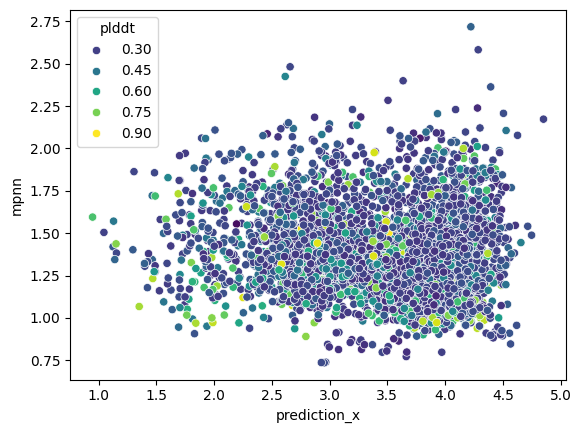

In [ ]:
sns.scatterplot(data = ESCMBA_predictions, y = 'mpnn', x ='prediction_x', hue = 'plddt', alpha =1, palette='viridis')

<Axes: xlabel='prediction_x', ylabel='plddt'>

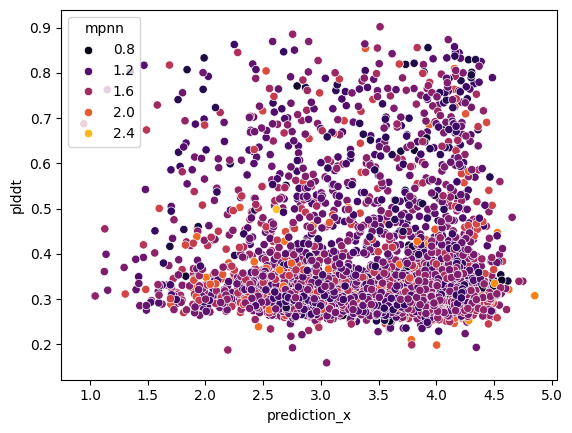

In [ ]:
sns.scatterplot(data =ESCMBA_predictions,y = 'plddt', x ='prediction_x', hue = 'mpnn', alpha =1, palette='inferno')

<Axes: xlabel='prediction_x', ylabel='plddt'>

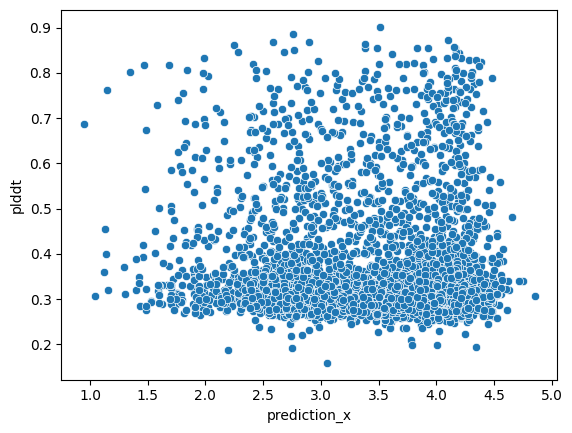

In [ ]:
sns.scatterplot(data =ESCMBA_predictions,y = 'plddt', x ='prediction_x')

Text(0.5, 1.0, 'RFdiffusion generated peptides with MHC structure fixed.')

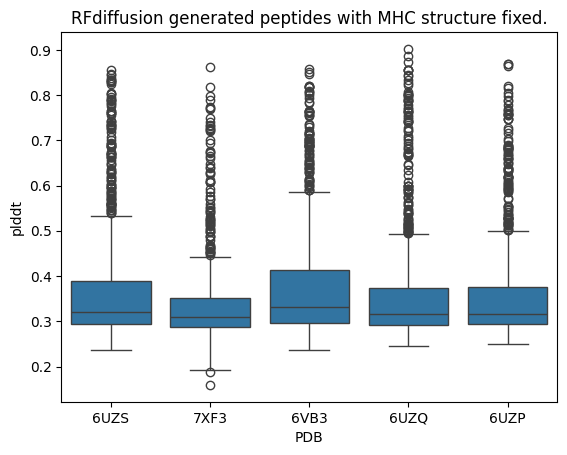

In [ ]:
sns.boxplot(data = ESCMBA_predictions, y = 'plddt', x ='PDB') #, palette='viridis')
plt.title("RFdiffusion generated peptides with MHC structure fixed.")

<Axes: xlabel='PDB', ylabel='prediction_x'>

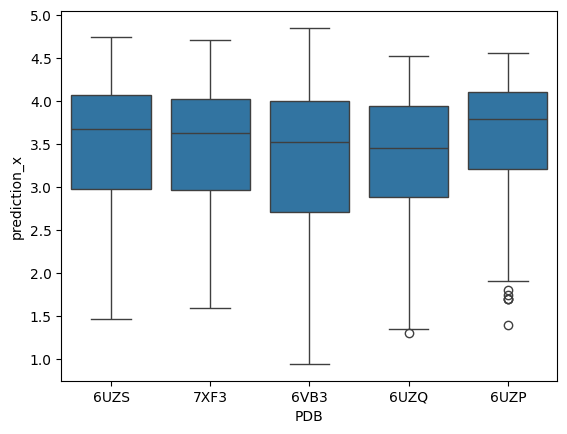

In [ ]:
sns.boxplot(data = ESCMBA_predictions, y = 'prediction_x', x ='PDB') #, palette='viridis')

<Axes: xlabel='prediction_x', ylabel='plddt'>

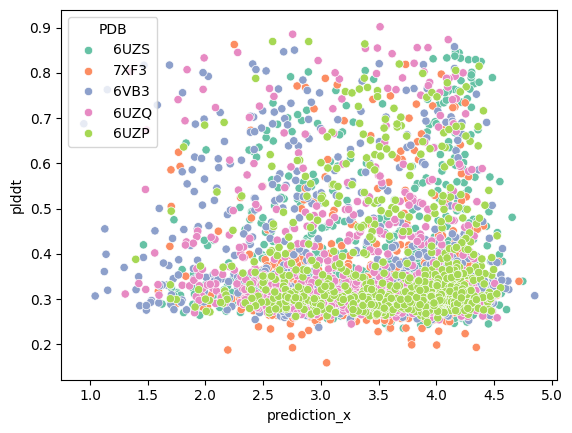

In [ ]:
sns.scatterplot(data =ESCMBA_predictions,y = 'plddt', x ='prediction_x', hue = 'PDB', palette='Set2')

<Axes: xlabel='prediction_x', ylabel='plddt'>

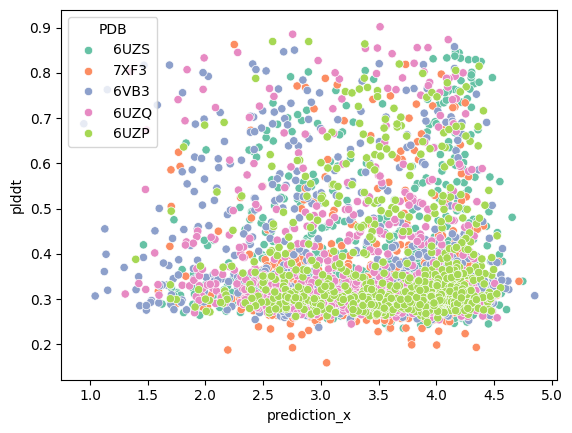

In [ ]:
sns.scatterplot(data =ESCMBA_predictions,y = 'plddt', x ='prediction_x', hue = 'PDB', palette='Set2')

In [ ]:
mhc_epitope_contacts = pd.read_csv("mhc_epitope_contacts.csv")

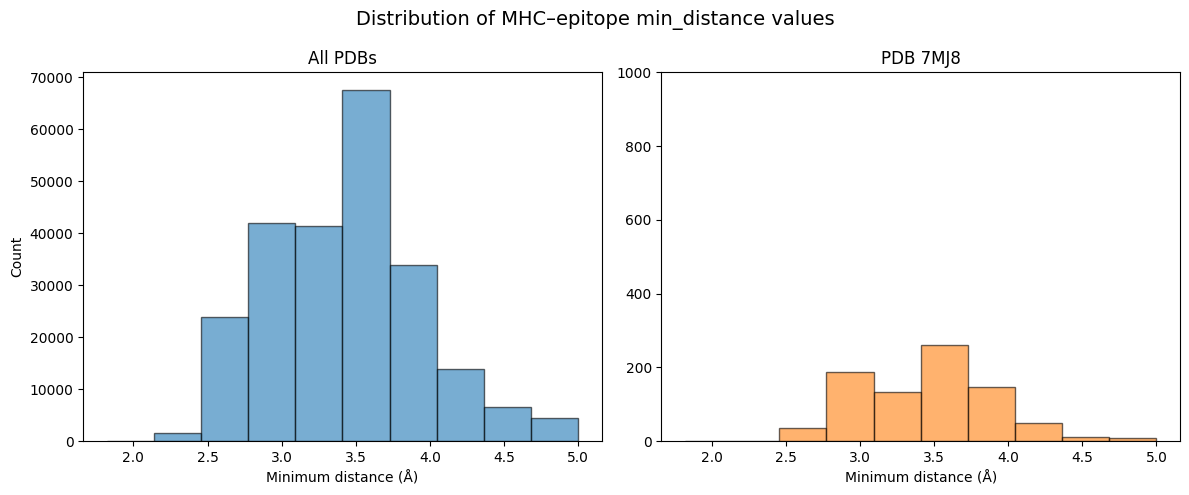

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- data ----------
all_vals    = mhc_epitope_contacts['min_distance'].dropna()
subset_vals = mhc_epitope_contacts.loc[
    mhc_epitope_contacts['pdb_id'] == '7KGQ', 'min_distance'
].dropna()

# consistent binning so the x-axes line up
bins = np.histogram_bin_edges(all_vals)

# ---------- plotting ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# panel 1 – all PDBs
axes[0].hist(all_vals,
             bins=bins,
             edgecolor='black',
             alpha=0.6)
axes[0].set_title('All PDBs')
axes[0].set_xlabel('Minimum distance (Å)')
axes[0].set_ylabel('Count')
# axes[0].set_ylim(0, 1000)      # same y-scale for easy comparison

# panel 2 – 7MJ8 only
axes[1].hist(subset_vals,
             bins=bins,
             edgecolor='black',
             alpha=0.6,
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])  # second default color
axes[1].set_title('PDB 7MJ8')
axes[1].set_xlabel('Minimum distance (Å)')
axes[1].set_ylim(0, 1000)

fig.suptitle('Distribution of MHC–epitope min_distance values', fontsize=14)
fig.tight_layout()
plt.show()


In [ ]:
pdb_chain_summary = pd.read_csv("pdb_chain_summary.csv").drop_duplicates()

In [ ]:
# Count chains per PDB
chain_counts = pdb_chain_summary.groupby('pdb_id').size().reset_index(name='num_chains')

# Filter to PDBs that have exactly 3 chains
three_chain_pdbs = chain_counts[chain_counts['num_chains'] == 3].sort_values(by='num_chains', ascending=False)


In [ ]:
# Filter the full chain summary to only 3-chain PDBs
filtered_summary = pdb_chain_summary[pdb_chain_summary['pdb_id'].isin(three_chain_pdbs['pdb_id'])]

In [ ]:

interactions = mhc_epitope_contacts.drop_duplicates().reset_index(drop=True)
# 1. Count how many distinct epitope residues contact each MHC residue
contact_counts = interactions.groupby(['mhc_chain', 'mhc_resnum'])['epitope_resnum'].nunique().reset_index()
contact_counts = contact_counts.rename(columns={'epitope_resnum': 'contact_count'})

# 2. Merge back into original interaction DataFrame
interactions = interactions.merge(contact_counts, on=['mhc_chain', 'mhc_resnum'], how='left')

# 3. Assign importance tier based on contact count
interactions["importance"] = interactions["contact_count"].map(
    lambda x: "core_hotspot" if x >= 4 else
              "high_contact" if x == 3 else
              "medium_contact" if x == 2 else
              "low_contact"
)


In [ ]:
job_params = []

# Only include PDBs with exactly 3 chains
chain_counts = filtered_summary.groupby('pdb_id').size()
three_chain_pdbs = chain_counts[chain_counts == 3].index.tolist()

for pdb_id in three_chain_pdbs:
    chains_df = filtered_summary[filtered_summary['pdb_id'] == pdb_id]
    chains = ",".join(chains_df['chain_id'].tolist())
    
    # Determine epitope chain: the one with smallest num_residues
    ep_chain = chains_df.loc[chains_df['num_residues'].idxmin(), 'chain_id']
    
    # Collect hotspot residues (core + high + medium)
    inter_df = interactions[
        (interactions['pdb_id'] == pdb_id) &
        (interactions['epitope_chain'] == ep_chain) &
        (interactions['importance'].isin(['core_hotspot','high_contact','medium_contact']))
    ]
    hotspots = sorted({f"{row['mhc_chain']}{row['mhc_resnum']}" for _, row in inter_df.iterrows()})

    if len(hotspots) < 5:
        inter_df = interactions[
            (interactions['pdb_id'] == pdb_id) &
            (interactions['epitope_chain'] == ep_chain) &
            (interactions['importance'].isin(['high_contact','medium_contact']))
        ]
    
    job_params.append({
        'pdb_id': pdb_id,
        'chains': chains,
        'epitope_chain': ep_chain,
        'hotspots': ",".join(hotspots)
    })

df_job_params = pd.DataFrame(job_params)

for _, row in df_job_params.iterrows():
    # get chain lengths for contigs construction
    lengths = {
        ch: filtered_summary.query(f"pdb_id=='{row.pdb_id}' & chain_id=='{ch}'").num_residues.item()
        for ch in row.chains.split(",")
    }
    # build contigs string
    parts = []
    for ch, L in lengths.items():

        if ch == row.epitope_chain:
            
            LENGTH = np.random.randint(7,13)
            L = LENGTH

            parts.append(f"0/{L}")
        else:
            parts.append(f"{ch}1-{L}/0")
    full_contigs = " ".join(parts)

In [ ]:
df_job_params['n_hospots'] = df_job_params['hotspots'].apply(lambda x: len(x.split(",")))

In [ ]:
df_job_params[df_job_params['pdb_id'] == '7KGQ']

,pdb_id,chains,epitope_chain,hotspots,n_hospots
74,7KGQ,"A,B,C",C,"A114,A116,A123,A124,A143,A146,A147,A150,A152,A...",50


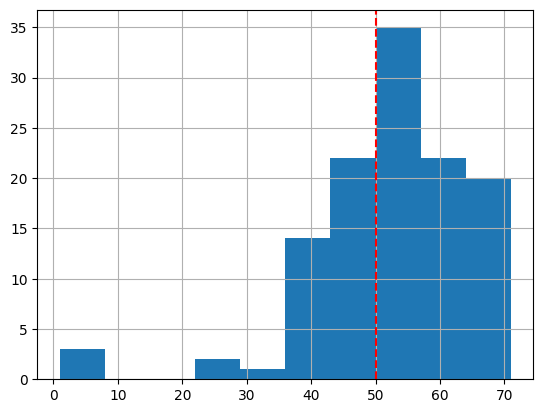

In [ ]:
df_job_params['n_hospots'].hist()
#veritcal line in the histogram
plt.axvline(x=50, color='r', linestyle='--')

In [ ]:
rfd_peptides['CREATED'] = rfd_peptides['CREATED'].str.split(" ", expand=True)[0]

<Axes: xlabel='CREATED', ylabel='plddt'>

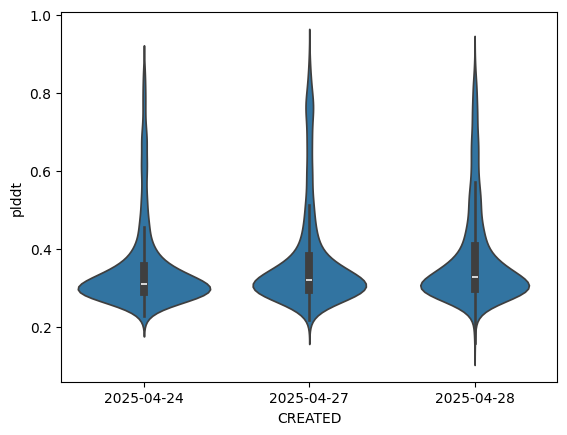

In [ ]:
sns.violinplot(data = rfd_peptides.sort_values(by='CREATED'), x = 'CREATED', y= 'plddt') #, palette='viridis')